In [1]:
"""
📌 Topic: Datetime Feature Engineering

🧠 Concept:
Datetime feature engineering means extracting useful parts from date/time columns
so machine learning models can understand time-based patterns.
Models do not understand raw dates directly, but they can learn from parts like:
year, month, day, weekday, quarter, weekend, etc.

📊 Example:
A sales dataset with an order_date column.
From that date, we can create features such as:
- year
- month
- day
- day_of_week
- is_weekend

⚙️ Code:
Implementation:
Convert the column to datetime format first, then extract useful features.

Example:
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day
df['day_of_week'] = df['order_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

📈 Visualization:
(optional)
You can visualize:
- sales by month
- sales by weekday
- trend over time

✅ Key Takeaways:
- Raw date columns are usually not directly useful for ML models
- Datetime feature engineering converts dates into meaningful numerical features
- Common extracted features are year, month, day, weekday, quarter, and weekend
- It helps models capture seasonality, trends, and weekly patterns
- Always convert date columns using pd.to_datetime() before extracting features
- Useful in sales, forecasting, customer behavior, transaction, and time-based datasets
"""

"\n📌 Topic: Datetime Feature Engineering\n\n🧠 Concept:\nDatetime feature engineering means extracting useful parts from date/time columns\nso machine learning models can understand time-based patterns.\nModels do not understand raw dates directly, but they can learn from parts like:\nyear, month, day, weekday, quarter, weekend, etc.\n\n📊 Example:\nA sales dataset with an order_date column.\nFrom that date, we can create features such as:\n- year\n- month\n- day\n- day_of_week\n- is_weekend\n\n⚙️ Code:\nImplementation:\nConvert the column to datetime format first, then extract useful features.\n\nExample:\ndf['order_date'] = pd.to_datetime(df['order_date'])\ndf['year'] = df['order_date'].dt.year\ndf['month'] = df['order_date'].dt.month\ndf['day'] = df['order_date'].dt.day\ndf['day_of_week'] = df['order_date'].dt.dayofweek\ndf['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)\n\n📈 Visualization:\n(optional)\nYou can visualize:\n- sales by month\n- sales by weekday\n- trend over 

# 🧪 Sample Dataset + Datetime Feature Engineering

In [2]:
import pandas as pd

In [3]:
# -----------------------------
# 1. Create sample dataset
# -----------------------------
data = {
    'order_date':[
        '2024-01-05',
        '2024-01-10',
        '2024-02-15',
        '2024-03-20',
        '2024-04-25',
        '2024-05-30',
        '2024-06-10',
        '2024-07-18',
        '2024-08-22',
        '2024-09-05'
    ],
    'sales': [200, 350, 400, 500, 450, 600, 700, 650, 720, 800]
}
df = pd.DataFrame(data)
print(df)

   order_date  sales
0  2024-01-05    200
1  2024-01-10    350
2  2024-02-15    400
3  2024-03-20    500
4  2024-04-25    450
5  2024-05-30    600
6  2024-06-10    700
7  2024-07-18    650
8  2024-08-22    720
9  2024-09-05    800


In [4]:
df.dtypes

order_date    object
sales          int64
dtype: object

⚙️ Datetime Feature Engineering

In [6]:
# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Extract features
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day
df['day_of_week'] = df['order_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print(df)


  order_date  sales  year  month  day  day_of_week  is_weekend
0 2024-01-05    200  2024      1    5            4           0
1 2024-01-10    350  2024      1   10            2           0
2 2024-02-15    400  2024      2   15            3           0
3 2024-03-20    500  2024      3   20            2           0
4 2024-04-25    450  2024      4   25            3           0
5 2024-05-30    600  2024      5   30            3           0
6 2024-06-10    700  2024      6   10            0           0
7 2024-07-18    650  2024      7   18            3           0
8 2024-08-22    720  2024      8   22            3           0
9 2024-09-05    800  2024      9    5            3           0


📊 Visualization Examples

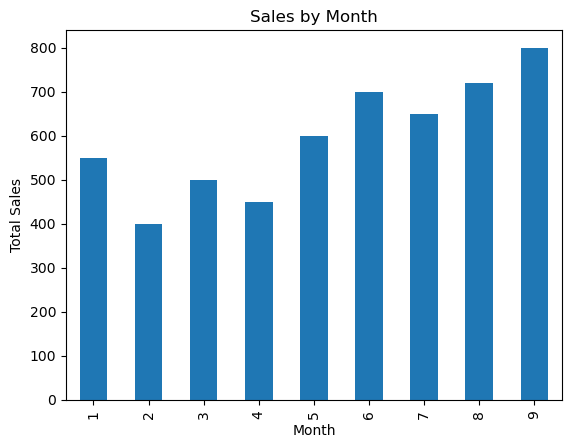

In [7]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('month')['sales'].sum()

monthly_sales.plot(kind='bar')
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

2️⃣ Sales by Day of Week

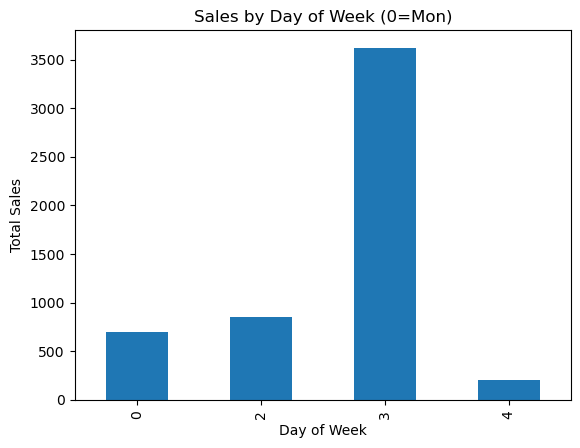

In [8]:
weekday_sales = df.groupby('day_of_week')['sales'].sum()

weekday_sales.plot(kind='bar')
plt.title("Sales by Day of Week (0=Mon)")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.show()

3️⃣ Sales Trend Over Time

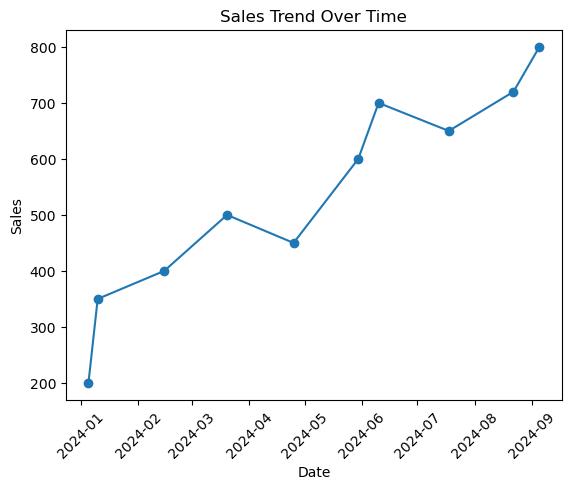

In [9]:
plt.plot(df['order_date'], df['sales'], marker='o')
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

```bash
🧠 What You’ll Learn From This
How to convert string → datetime
How to extract time-based features
How to analyze patterns like:
monthly trends 📈
weekday behavior 📅
overall growth 📊

🔥 Pro Tip (Add this experiment)

In [10]:
df.groupby('is_weekend')['sales'].mean()

is_weekend
0    537.0
Name: sales, dtype: float64

# Chapter 2: 🚀 Advanced Datetime Features

```bash
🔁 1. Lag Features (VERY IMPORTANT)
👉 Used to capture past behavior

In [12]:
# Previous day's sales
df['lag_1'] = df['sales'].shift(1)

# 2 days before
df['lag_2'] = df['sales'].shift(2)

df.head()

,order_date,sales,year,month,day,day_of_week,is_weekend,lag_1,lag_2
0,2024-01-05,200,2024,1,5,4,0,NaN,NaN
1,2024-01-10,350,2024,1,10,2,0,200.0,NaN
2,2024-02-15,400,2024,2,15,3,0,350.0,200.0
3,2024-03-20,500,2024,3,20,2,0,400.0,350.0
4,2024-04-25,450,2024,4,25,3,0,500.0,400.0


```bash
🧠 Meaning:
Today’s sales depends on yesterday’s sales

```bash
📊 2. Rolling Features (Moving Average)
👉 Smooth trends

In [14]:
# 3-day moving average
df['rolling_mean_3'] = df['sales'].rolling(window=3).mean()

# 3-day max
df['rolling_max_3'] = df['sales'].rolling(window=3).max()
df.head()

,order_date,sales,year,month,day,day_of_week,is_weekend,lag_1,lag_2,rolling_mean_3,rolling_max_3
0,2024-01-05,200,2024,1,5,4,0,NaN,NaN,NaN,NaN
1,2024-01-10,350,2024,1,10,2,0,200.0,NaN,NaN,NaN
2,2024-02-15,400,2024,2,15,3,0,350.0,200.0,316.666667,400.0
3,2024-03-20,500,2024,3,20,2,0,400.0,350.0,416.666667,500.0
4,2024-04-25,450,2024,4,25,3,0,500.0,400.0,450.000000,500.0


```bash
🧠 Meaning:
Average of last 3 days → trend signal

```bash
⏳ 3. Expanding Features
👉 Cumulative behavior

In [16]:
df['expanding_mean'] = df['sales'].expanding().mean()
df.head()

,order_date,sales,year,month,day,day_of_week,is_weekend,lag_1,lag_2,rolling_mean_3,rolling_max_3,expanding_mean
0,2024-01-05,200,2024,1,5,4,0,NaN,NaN,NaN,NaN,200.000000
1,2024-01-10,350,2024,1,10,2,0,200.0,NaN,NaN,NaN,275.000000
2,2024-02-15,400,2024,2,15,3,0,350.0,200.0,316.666667,400.0,316.666667
3,2024-03-20,500,2024,3,20,2,0,400.0,350.0,416.666667,500.0,362.500000
4,2024-04-25,450,2024,4,25,3,0,500.0,400.0,450.000000,500.0,380.000000


```bash
🧠 Meaning:
Average of ALL previous values

📅 4. Advanced Date Features

In [18]:
df['week_of_year'] = df['order_date'].dt.isocalendar().week
df['quarter'] = df['order_date'].dt.quarter
df['is_month_start'] = df['order_date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['order_date'].dt.is_month_end.astype(int)
df.head()

,order_date,sales,year,month,day,day_of_week,is_weekend,lag_1,lag_2,rolling_mean_3,rolling_max_3,expanding_mean,week_of_year,quarter,is_month_start,is_month_end
0,2024-01-05,200,2024,1,5,4,0,NaN,NaN,NaN,NaN,200.000000,1,1,0,0
1,2024-01-10,350,2024,1,10,2,0,200.0,NaN,NaN,NaN,275.000000,2,1,0,0
2,2024-02-15,400,2024,2,15,3,0,350.0,200.0,316.666667,400.0,316.666667,7,1,0,0
3,2024-03-20,500,2024,3,20,2,0,400.0,350.0,416.666667,500.0,362.500000,12,1,0,0
4,2024-04-25,450,2024,4,25,3,0,500.0,400.0,450.000000,500.0,380.000000,17,2,0,0


```bash
🎯 5. Cyclical Features (VERY ADVANCED 🔥)
👉 Important for ML models (handles circular nature)

In [19]:
import numpy as np

df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
df.head()

,order_date,sales,year,month,day,day_of_week,is_weekend,lag_1,lag_2,rolling_mean_3,rolling_max_3,expanding_mean,week_of_year,quarter,is_month_start,is_month_end,month_sin,month_cos
0,2024-01-05,200,2024,1,5,4,0,NaN,NaN,NaN,NaN,200.000000,1,1,0,0,0.500000,8.660254e-01
1,2024-01-10,350,2024,1,10,2,0,200.0,NaN,NaN,NaN,275.000000,2,1,0,0,0.500000,8.660254e-01
2,2024-02-15,400,2024,2,15,3,0,350.0,200.0,316.666667,400.0,316.666667,7,1,0,0,0.866025,5.000000e-01
3,2024-03-20,500,2024,3,20,2,0,400.0,350.0,416.666667,500.0,362.500000,12,1,0,0,1.000000,6.123234e-17
4,2024-04-25,450,2024,4,25,3,0,500.0,400.0,450.000000,500.0,380.000000,17,2,0,0,0.866025,-5.000000e-01


```bash
🧠 Why?
Because:
December (12) is close to January (1)

Normal numbers don’t capture that ❌
Cyclical encoding does ✅

📈 6. Visualizing Rolling Trend

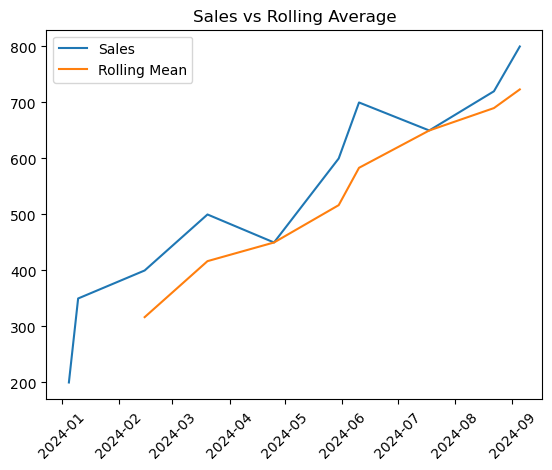

In [20]:
import matplotlib.pyplot as plt

plt.plot(df['order_date'], df['sales'], label='Sales')
plt.plot(df['order_date'], df['rolling_mean_3'], label='Rolling Mean')

plt.legend()
plt.title("Sales vs Rolling Average")
plt.xticks(rotation=45)
plt.show()

```bash
⚠️ Important Notes
Lag creates NaN

In [21]:
df = df.dropna()
df.head()

,order_date,sales,year,month,day,day_of_week,is_weekend,lag_1,lag_2,rolling_mean_3,rolling_max_3,expanding_mean,week_of_year,quarter,is_month_start,is_month_end,month_sin,month_cos
2,2024-02-15,400,2024,2,15,3,0,350.0,200.0,316.666667,400.0,316.666667,7,1,0,0,8.660254e-01,5.000000e-01
3,2024-03-20,500,2024,3,20,2,0,400.0,350.0,416.666667,500.0,362.500000,12,1,0,0,1.000000e+00,6.123234e-17
4,2024-04-25,450,2024,4,25,3,0,500.0,400.0,450.000000,500.0,380.000000,17,2,0,0,8.660254e-01,-5.000000e-01
5,2024-05-30,600,2024,5,30,3,0,450.0,500.0,516.666667,600.0,416.666667,22,2,0,0,5.000000e-01,-8.660254e-01
6,2024-06-10,700,2024,6,10,0,0,600.0,450.0,583.333333,700.0,457.142857,24,2,0,0,1.224647e-16,-1.000000e+00


🧠 Final Understanding

| Feature   | Purpose          |
| --------- | ---------------- |
| lag       | past influence   |
| rolling   | smoothing        |
| expanding | cumulative trend |
| cyclical  | seasonal pattern |


```bash
🔥 Real Use Cases

Used in:

sales forecasting 📊
stock prediction 📉
demand prediction 📦
user activity tracking 📱

```bash
🧠 Simple Mental Model
👉 Time data is not just “date”

It is:
- pattern + trend + seasonality + memory
